In [1]:
import torch

repo_dir = "./dinov3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.hub.load(
    repo_dir,
    "dinov3_vith16plus",
    source="local",
    weights="dinov3_vith16plus_pretrain_lvd1689m.pth",
).to(device)

model.eval()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x SelfAttentionBlock(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1280, out_features=3840, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=1280, out_features=5120, bias=True)
        (w2): Linear(in_features=1280, out_features=5120, bias=True)
        (w3): Linear(in_features=5120, out_features=1280, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((

In [2]:
import torch
from torchvision.transforms import v2
from PIL import Image


# 1. Standard DINO normalization
def make_transform(resize_size: int = 768):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])


transform = make_transform(resize_size=224)
img = Image.open("ducks.jpg").convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    # Use forward_features to get the full token dictionary
    features = model.forward_features(img_t)

    # DINOv3 Output Keys: ['x_norm_clstoken', 'x_norm_patchtokens', 'x_storage_tokens', ...]
    patch_tokens = features["x_norm_patchtokens"]
    cls_token = features["x_norm_clstoken"]

print(f"Patch Tokens Shape: {patch_tokens.shape}")

Patch Tokens Shape: torch.Size([1, 196, 1280])


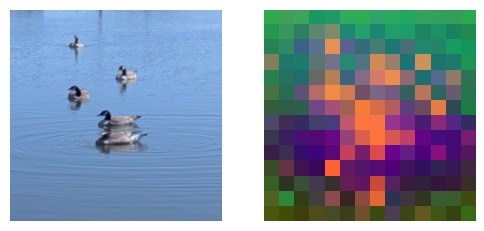

In [3]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Flatten and move to CPU
tokens = patch_tokens.squeeze(0).cpu().numpy() # [196, 1280]

# Project to 3 components (for RGB)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(tokens)

# Reshape back to the 14x14 grid
grid_size = int(np.sqrt(tokens.shape[0]))
pca_img = pca_features.reshape(grid_size, grid_size, 3)

# Normalize to [0, 1] for visualization
pca_img = (pca_img - pca_img.min()) / (pca_img.max() - pca_img.min())

fig, ax = plt.subplots(1, 2, figsize=(6, 6))

img_t_cpu = img_t.cpu().squeeze(0).permute(1, 2, 0)
img_t_cpu = (img_t_cpu - img_t_cpu.min()) / (img_t_cpu.max() - img_t_cpu.min())

ax[0].imshow(img_t_cpu)
ax[0].axis("off")

ax[1].imshow(pca_img)
ax[1].axis("off")
plt.show()

### 1. Dataset Preparation

For our MVP, we'll use PASCAL VOC. Since this is Weakly-Supervised Semantic Segmentation (WSSS) with image-level tags, we treat the dataset as a multi-label classification problem during training. 

We can load the standard Segmentation dataset, but instead of using the full dense mask for training, we extract simply the unique classes present in the image. We'll still keep the ground-truth mask around strictly for visualization and evaluating how well our WSSS method performs.

In [4]:
import torchvision
from torch.utils.data import DataLoader, Subset

# Download=True if needed
voc_segmentation = torchvision.datasets.VOCSegmentation(
    root="./data", 
    year="2012", 
    image_set="train", 
    download=True
)

# We are now ready for the full dataset!
# dataset_subset = Subset(voc_segmentation, range(100))

def wsss_collate_fn(batch):
    images, gt_masks = [], []
    image_level_labels = []
    
    for img, mask in batch:
        # Preprocess image
        images.append(transform(img))
        mask_t = torch.tensor(np.array(mask), dtype=torch.long)
        gt_masks.append(mask_t)
        
        # --- Crucial Concept for WSSS ---
        # Derive image-level tags from the GT mask by finding unique classes
        # Ignore 0 (background) and 255 (void/ignore border)
        unique_classes = torch.unique(mask_t)
        unique_classes = unique_classes[(unique_classes != 0) & (unique_classes != 255)]
        
        # Create a multi-label binary vector [num_classes=20]
        # PASCAL VOC has 20 foreground classes. 
        # (index 0 corresponds to class 1, etc.)
        label_vec = torch.zeros(20, dtype=torch.float32)
        if len(unique_classes) > 0:
            label_vec[unique_classes - 1] = 1.0
            
        image_level_labels.append(label_vec)
        
    return torch.stack(images), gt_masks, torch.stack(image_level_labels)

# Full dataloader
dataloader = DataLoader(voc_segmentation, batch_size=32, collate_fn=wsss_collate_fn, shuffle=True)


### 2. Model Architecture

We already have a `DINOv3Segmenter` that predicts dense logits (mask). Since we only have **image-level tags**, how do we compute a loss?

**The Solution (CAM - Class Activation Mapping):**
We take the dense classification predictions (the $20\times H \times W$ spatial map output by the segmenter) and apply **Global Average Pooling (GAP)** over the spatial dimensions, giving us 20 predictions for the whole image. We then apply `BCEWithLogitsLoss` to compare this pooled prediction vs our ground-truth image-level tags.

Because the model is forced to recognize classes based on this spatial aggregation, the only way it can confidently predict a class is to have high activation in the regions where the object actually exists! Thus, the spatial pre-GAP logits act as our "learned segmentation."

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class DINOv3Segmenter(nn.Module):
    def __init__(self, num_classes=20): # 20 foreground classes for VOC
        super().__init__()
        # 1x1 Conv is effectively a linear layer per patch
        self.head = nn.Conv2d(1280, num_classes, kernel_size=1)
        
    def forward(self, patch_tokens, grid_size=(48, 48)):
        # Reshape [B, 2304, 1280] -> [B, 1280, 48, 48]
        x = patch_tokens.permute(0, 2, 1).reshape(-1, 1280, *grid_size)
        spacial_logits = self.head(x) # Spatial classification masks [B, 20, 48, 48]
        
        # GAP for WSSS: Spatial Pooling gives us [B, 20] image-level tags
        image_level_logits = spacial_logits.mean(dim=(2, 3)) 
        
        # We return both:
        # 1. image_level_logits for backpropagating the tag loss
        # 2. spacial_logits to visualize the Class Activation Maps (pseudo-masks)
        return image_level_logits, spacial_logits

### 3. Training Loop

Now we train the linear head on the image tags using DINO frozen tokens.
BCEWithLogitsLoss is the standard loss used here since multiple classes (tags) can exist on any single image (multi-label).

Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch [1/10], Loss: 0.3789


Epoch 2:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch [2/10], Loss: 0.2410


Epoch 3:   0%|          | 0/46 [00:00<?, ?it/s]

...

Epoch [8/10], Loss: 0.1118


Epoch 9:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch [9/10], Loss: 0.1035


Epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch [10/10], Loss: 0.0967


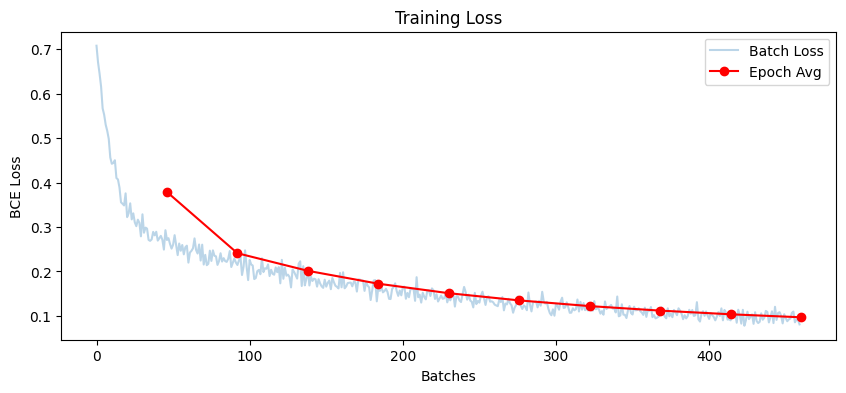

In [6]:
from tqdm.notebook import tqdm
import torch.optim as optim

# Instantiate our segmenter
segmenter = DINOv3Segmenter(num_classes=20).to(device)
optimizer = optim.Adam(segmenter.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# Training for a few epochs as a minimum viable demonstration
num_epochs = 10
epoch_losses = []
batch_losses = []

import matplotlib.pyplot as plt

for epoch in range(num_epochs):
    segmenter.train()
    epoch_loss = 0.0
    
    # We freeze DINO, and just train the 1x1 conv on top using image-level tags.
    for i, (images, gt_masks, image_level_labels) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
        images = images.to(device)
        image_level_labels = image_level_labels.to(device)
        
        # 1. Forward frozen DINO
        with torch.no_grad():
            features = model.forward_features(images)
            patch_tokens = features['x_norm_patchtokens']
            
            # The model ends in 16plus, meaning patch size is 16! 
            # 224 / 16 = 14, so our grid is 14x14
            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            grid_size = (grid_dim, grid_dim)
            
        # 2. Forward Segmenter
        optimizer.zero_grad()
        # Outputs: 
        #   img_logits : [B, 20] from the gap
        #   spatial_logits : [B, 20, 16, 16] - pseudo segmentation masks
        img_logits, spatial_logits = segmenter(patch_tokens, grid_size=grid_size)
        
        # 3. Calculate Loss (Only on image level!)
        # No pixel-level supervision used!
        loss = criterion(img_logits, image_level_labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_losses.append(loss.item())
        
    avg_loss = epoch_loss/len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(batch_losses, label='Batch Loss', alpha=0.3)
epoch_ticks = [i * len(dataloader) for i in range(1, num_epochs+1)]
plt.plot(epoch_ticks, epoch_losses, label='Epoch Avg', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Batches')
plt.ylabel('BCE Loss')
plt.legend()
plt.show()

### 4. Viewing the Pseudo-Masks (CAMs)

Now we display our image and the predicted mask to verify if it successfully localized the object utilizing purely image-level tags from our GAP linear classification head gap step above.

Ground truth image labels (1 for object):  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.], device='cuda:0')


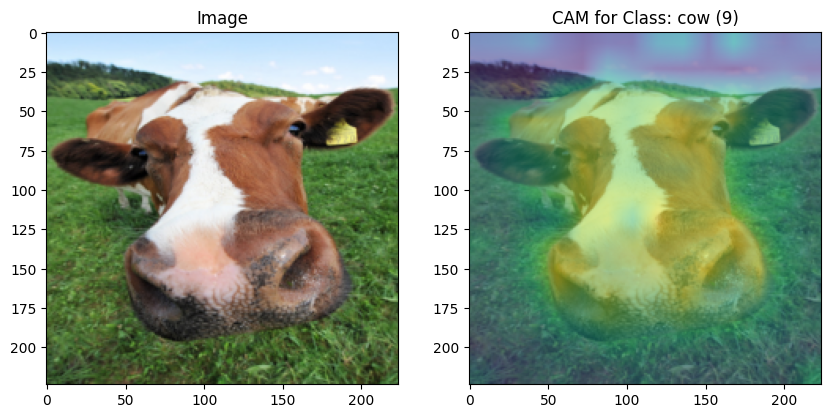

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Taking the last batch of images and spatial_logits from the loop above
# Images shape: [4, 3, 224, 224]
# pseudo_masks shape: [4, 20, 14, 14]

idx = 0 # first image in the last batch
print("Ground truth image labels (1 for object): ", image_level_labels[idx])

# PASCAL Classes to labels offset mapping (example)
# Since label index logic (class_number - 1)
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 
    'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 
    'sofa', 'train', 'tvmonitor'
]
highest_prob_class = image_level_labels[idx].argmax().item()
class_name = VOC_CLASSES[highest_prob_class]

# Get image
image_to_show = images[idx].cpu().permute(1, 2, 0).numpy()
# Un-normalize image
image_to_show = image_to_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image_to_show = np.clip(image_to_show, 0, 1)

# Get the Class Activation Map
# For visualization: interpolate 14x14 to original 224x224 size
spatial_logit_map_for_class = spatial_logits[idx, highest_prob_class].detach().unsqueeze(0).unsqueeze(0)
cam_resized = F.interpolate(spatial_logit_map_for_class, size=(224, 224), mode='bilinear').squeeze()

# Scale activation maps
cam_disp = cam_resized.cpu().numpy()
cam_disp = (cam_disp - cam_disp.min()) / (cam_disp.max() - cam_disp.min())

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_to_show)
ax[0].set_title(f"Image")
ax[1].imshow(cam_disp)
ax[1].set_title(f"CAM for Class: {class_name} ({highest_prob_class})")

# Display GT overlay to compare
ax[1].imshow(image_to_show, alpha=0.5)

plt.show()

### 5. Using SAM to Generate Dense Pseudo-Masks

Now we will use the officially downloaded SAM (Segment Anything Model) from Meta. Our goal is to extract **Points** and **Bounding Boxes** from our low-resolution CAMs to act as prompts. 
SAM will then give us a perfectly localized, high-resolution silhouette of our object.


In [8]:
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.patches as patches

# 1. Load the SAM model
sam_checkpoint = "./sam_vit_h_4b8939.pth"
model_type = "vit_h"

print("Loading SAM (might take a few seconds)...")
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Initialize the predictor
predictor = SamPredictor(sam)

# SAM expects HWC uint8 array (0-255)
image_sam_format = (image_to_show * 255.0).astype(np.uint8)
predictor.set_image(image_sam_format)

Loading SAM (might take a few seconds)...


With SAM loaded into memory, we formulate logic to read the `cam_disp` activation map from the previous step and extrapolate what it thinks could be considered the "subject". We simply calculate the `min` & `max` coordinates where the threshold succeeds significantly to make our bounding box, and the coordinates to the highest peak in the CAM for our "positive foreground point".

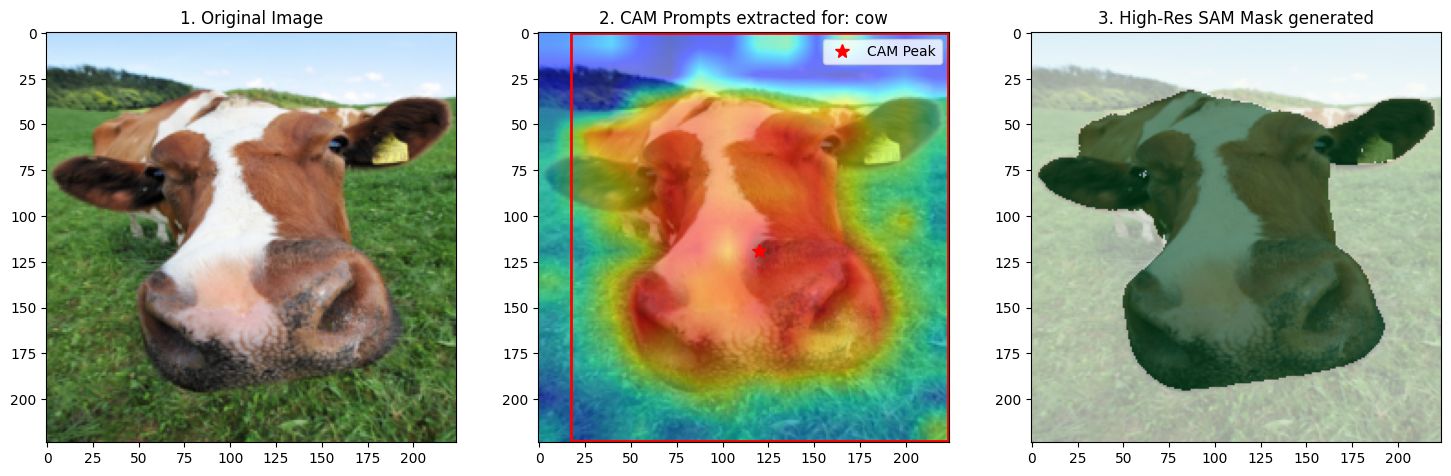

In [9]:
# 2. Extract Prompts from CAM
# The background is generally < 0.2, and object is > 0.6
THRESHOLD = 0.5  
foreground_mask = cam_disp > THRESHOLD

# Get bounding box (Min and Max X, Y of the foreground mask)
y_indices, x_indices = np.where(foreground_mask)

if len(x_indices) > 0:
    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    input_box = np.array([x_min, y_min, x_max, y_max])
else:
    # Fallback to whole image if something goes wrong
    input_box = np.array([0, 0, 223, 223]) 
    
# Get positive point (The peak activation of our CAM)
# This serves as a strong hint to SAM about where the object strictly lies
max_y, max_x = np.unravel_index(np.argmax(cam_disp, axis=None), cam_disp.shape)
input_point = np.array([[max_x, max_y]])
# Label '1' designates it as a foreground point
input_label = np.array([1]) 

# 3. Request dense mask from SAM using our prompts
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False, # We only need the best single mask
)

# Extracts the high-res 224x224 mask SAM created
sam_pseudo_mask = masks[0] 

# 4. Display all the Prompting vs SAM Final result
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# A. Display original image
ax[0].imshow(image_to_show)
ax[0].set_title("1. Original Image")

# B. Display Prompts (CAM overlay + Box + Peak Point)
ax[1].imshow(image_to_show)
ax[1].imshow(cam_disp, alpha=0.5, cmap='jet')
# Draw SAM Bounding Box Prompt
rect = patches.Rectangle((input_box[0], input_box[1]), 
                         input_box[2]-input_box[0], 
                         input_box[3]-input_box[1], 
                         linewidth=2, edgecolor='red', facecolor='none')
ax[1].add_patch(rect)
# Draw SAM Peak Point Prompt
ax[1].plot(max_x, max_y, 'r*', markersize=10, label="CAM Peak")
ax[1].set_title(f"2. CAM Prompts extracted for: {class_name}")
ax[1].legend()

# C. Display resulting High Res SAM Mask 
ax[2].imshow(image_to_show)
# Color the mask area with a bright green so it's clearly visible
ax[2].imshow(sam_pseudo_mask, alpha=0.6, cmap='Greens')
ax[2].set_title(f"3. High-Res SAM Mask generated")

plt.show()

### 6. Quantitative Evaluation (mIoU) and Prompt Engineering

What is left in a WSSS pipeline? The final step is typically to process the **entire dataloader** generating SAM pseudo-masks, and using those masks as the ground truth targets for a **fully supervised segmentation model** (like a DeepLabV3, Mask2Former, or another DINO segmenter). 

However, before we do that massive dataset generation step, we must evaluate how well our pseudo-labels actually align with the ground truth! Since SAM allows multiple prompt types (Points, Bounding Boxes, or Both), we can empirically measure which prompt approach generates the best *Intersection-over-Union (mIoU)* on a validation subset. We will also sort by the lowest mIoU to intuitively observe our model's "Failure Modes".

In [13]:
from operator import gt
import cv2
import numpy as np
import torch
import torch.nn.functional as F

def extract_prompts(cam, threshold=0.65, min_area=400):
    """Helper to convert a low-res CAM into multiple SAM Prompts using Connected Components."""
    foreground = (cam > threshold).astype(np.uint8) * 255
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(foreground, connectivity=8)
    
    boxes = []
    points = []
    
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] < min_area:
            continue
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        boxes.append(np.array([x, y, x+w, y+h]))
        
        # Max activation in this specific blob
        comp_mask = (labels == i)
        masked_cam = cam.copy()
        masked_cam[~comp_mask] = -1
        max_y, max_x = np.unravel_index(np.argmax(masked_cam, axis=None), cam.shape)
        points.append(np.array([max_x, max_y]))
        
    if not boxes:
        boxes.append(np.array([0, 0, cam.shape[1]-1, cam.shape[0]-1]))
        max_y, max_x = np.unravel_index(np.argmax(cam, axis=None), cam.shape)
        points.append(np.array([max_x, max_y]))
        
    return boxes, points

def calc_iou(pred_bin, gt_bin, valid_mask):
    """Calculates Intersection over Union securely omitting invalid void/ignore regions (value 255)."""
    intersect = np.logical_and(pred_bin & valid_mask, gt_bin & valid_mask).sum()
    union = np.logical_or(pred_bin & valid_mask, gt_bin & valid_mask).sum()
    return float(intersect) / float(union + 1e-5) # Added epsilon to prevent zero-div

NUM_EVAL_IMAGES = 64
images_evaluated = 0
eval_results = []
segmenter.eval()

from segment_anything import SamAutomaticMaskGenerator
mask_generator = SamAutomaticMaskGenerator(sam)

print("Evaluating Prompt Techniques against Ground Truth... (Takes ~10-20 seconds)")
for images, gt_masks, image_level_labels in dataloader:
    if images_evaluated >= NUM_EVAL_IMAGES:
        break
        
    images = images.to(device)
    
    with torch.no_grad():
        features = model.forward_features(images)
        patch_tokens = features['x_norm_patchtokens']
        grid_dim = int(patch_tokens.shape[1] ** 0.5)
        _, spatial_logits = segmenter(patch_tokens, grid_size=(grid_dim, grid_dim))
        
    for i in range(images.shape[0]):
        if images_evaluated >= NUM_EVAL_IMAGES:
            break
            
        img_t = images[i].cpu()
        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        img_uint8 = (img_np * 255.0).astype(np.uint8)
        
        # 1. Encode image to SAM (Compute intensive step)
        predictor.set_image(img_uint8)
        auto_masks = mask_generator.generate(img_uint8)
        
        # Original GT Mask
        gt = gt_masks[i].numpy()
        gt_224 = cv2.resize(gt, (224, 224), interpolation=cv2.INTER_NEAREST)
        valid_mask = (gt_224 != 255)
        
        # PASCAL can have multiple foreground classes. We evaluate each instance.
        present_classes = torch.where(image_level_labels[i] > 0)[0].tolist()
        for cls_idx in present_classes:
            gt_binary = (gt_224 == (cls_idx + 1))
            
            # Form CAM
            cam = spatial_logits[i, cls_idx].unsqueeze(0).unsqueeze(0)
            cam = F.interpolate(cam, size=(224, 224), mode='bilinear').squeeze().cpu().numpy()
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            
            boxes, points = extract_prompts(cam, threshold=0.65, min_area=400)
            
            mask_point = np.zeros((224, 224), dtype=bool)
            mask_box = np.zeros((224, 224), dtype=bool)
            mask_both = np.zeros((224, 224), dtype=bool)
            
            for box, point in zip(boxes, points):
                p_coord = np.array([point])
                p_label = np.array([1])
                
                m_p, _, _ = predictor.predict(point_coords=p_coord, point_labels=p_label, multimask_output=False)
                m_b, _, _ = predictor.predict(box=box, multimask_output=False)
                m_both, _, _ = predictor.predict(point_coords=p_coord, point_labels=p_label, box=box, multimask_output=False)
                
                mask_point |= m_p[0]
                mask_box |= m_b[0]
                mask_both |= m_both[0]
            
            # 3. "Everything" Overlap approach
            cam_foreground = cam > 0.65
            mask_auto = np.zeros((224, 224), dtype=bool)
            for ann in auto_masks:
                m = ann['segmentation']
                # If the majority of this SAM segment is inside the CAM foreground, keep it
                if (m & cam_foreground).sum() / (m.sum() + 1e-8) > 0.7:
                    mask_auto |= m
            
            iou_p = calc_iou(mask_point, gt_binary, valid_mask)
            iou_b = calc_iou(mask_box, gt_binary, valid_mask)
            iou_both = calc_iou(mask_both, gt_binary, valid_mask)
            iou_auto = calc_iou(mask_auto, gt_binary, valid_mask)
            
            eval_results.append({
                'img': img_np,
                'cls': cls_idx,
                'iou_point': iou_p,
                'iou_box': iou_b,
                'iou_both': iou_both,
                'iou_auto': iou_auto,
                'cam': cam,
                'mask_both': mask_both,
                'mask_auto': mask_auto,
                'gt_binary': gt_binary,
                'boxes': boxes,
                'points': points
            })
            
        images_evaluated += 1

# Aggregate scores
if len(eval_results) > 0:
    print("\n--- Validation Performance (mIoU) ---")
    print(f"Point-Only Prompts: {np.mean([r['iou_point'] for r in eval_results]):.4f}")
    print(f"Bounding Box Prompts: {np.mean([r['iou_box'] for r in eval_results]):.4f}")
    print(f"Point+Box Prompts: {np.mean([r['iou_both'] for r in eval_results]):.4f}")
    print(f"Auto-Everything Filtered: {np.mean([r['iou_auto'] for r in eval_results]):.4f}")

Evaluating Prompt Techniques against Ground Truth... (Takes ~10-20 seconds)

--- Validation Performance (mIoU) ---
Point-Only Prompts: 0.3094
Bounding Box Prompts: 0.5190
Point+Box Prompts: 0.5415
Auto-Everything Filtered: 0.5249


In [15]:
# 7. Interactive Failure Mode Inspector

import ipywidgets as widgets
from IPython.display import display, clear_output

# Calculate object size percentage to help ignore tiny background objects
for res in eval_results:
    res['obj_size_pct'] = (res['gt_binary'].sum() / (224*224)) * 100

# --- Analyze Worst Classes ---
class_stats = {}
for res in eval_results:
    cls = res['cls']
    if cls not in class_stats:
        class_stats[cls] = {'count': 0, 'iou_auto': [], 'iou_both': [], 'iou_box': [], 'iou_point': []}
    class_stats[cls]['count'] += 1
    class_stats[cls]['iou_auto'].append(res['iou_auto'])
    class_stats[cls]['iou_both'].append(res['iou_both'])
    class_stats[cls]['iou_box'].append(res['iou_box'])
    class_stats[cls]['iou_point'].append(res['iou_point'])

class_summary = []
for cls, stats in class_stats.items():
    class_summary.append({
        'class': VOC_CLASSES[cls],
        'cls_idx': cls,
        'count': stats['count'],
        'iou_auto': np.mean(stats['iou_auto']),
        'iou_both': np.mean(stats['iou_both'])
    })
class_summary.sort(key=lambda x: x['iou_auto'])

print("--- Worst Performing Classes (by Auto-Everything mIoU) ---")
for stat in class_summary[:5]:
    print(f"{stat['class'].upper()}: {stat['iou_auto']:.3f} (Count: {stat['count']})")
print("----------------------------------------------------------")

out = widgets.Output()

# Filters and State
sort_dropdown = widgets.Dropdown(
    options=[('Auto-Everything', 'iou_auto'), ('Box+Point', 'iou_both'), ('Box-Only', 'iou_box'), ('Point-Only', 'iou_point')],
    value='iou_auto',
    description='Sort Worst By:',
    style={'description_width': 'initial'}
)

class_options = [('All Classes', -1)] + [(c['class'].upper(), c['cls_idx']) for c in class_summary]
class_dropdown = widgets.Dropdown(
    options=class_options,
    value=-1,
    description='Filter Class:',
    style={'description_width': 'initial'}
)

btn_prev = widgets.Button(description="< Previous", icon="step-backward")
btn_next = widgets.Button(description="Next >", icon="step-forward")
label_info = widgets.Label(value="")

filtered_results = []
current_idx = 0

def update_view():
    global current_idx, filtered_results
    
    max_idx = len(filtered_results) - 1
    if max_idx < 0:
        btn_prev.disabled = True
        btn_next.disabled = True
        label_info.value = "   No results found.   "
        with out:
            clear_output(wait=True)
            print("No examples match the selected filters.")
        return

    btn_prev.disabled = (current_idx == 0)
    btn_next.disabled = (current_idx == max_idx)
    label_info.value = f"   Rank: {current_idx + 1} / {max_idx + 1}   "
    
    with out:
        clear_output(wait=True)
        res = filtered_results[current_idx]
        class_name = VOC_CLASSES[res['cls']]
        
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f"Failure Rank {current_idx + 1} for '{sort_dropdown.label}': {class_name.upper()} | Object Size: {res['obj_size_pct']:.1f}%", fontsize=14)
        
        # Left: Image
        axes[0].imshow(res['img'])
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # Mid: CAM Output + Prompts
        axes[1].imshow(res['img'])
        axes[1].imshow(res['cam'], cmap='jet', alpha=0.5)
        import matplotlib.patches as patches
        for box, point in zip(res['boxes'], res['points']):
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                     linewidth=2, edgecolor='red', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].plot(point[0], point[1], 'y*', markersize=10) # Yellow star for points
            
        axes[1].set_title("CAM & Extracted Prompts")
        axes[1].axis('off')
        
        # Right: SAM Box+Point Result vs Ground Truth
        axes[2].imshow(res['img'])
        axes[2].imshow(res['mask_both'], cmap='Greens', alpha=0.5)
        axes[2].contour(res['gt_binary'], levels=[0.5], colors=['red'], linewidths=2)
        axes[2].set_title(f"SAM Box+Point | IoU: {res['iou_both']:.3f}")
        axes[2].axis('off')
        
        # Far Right: SAM Auto 'Everything' Result vs Ground Truth
        axes[3].imshow(res['img'])
        axes[3].imshow(res['mask_auto'], cmap='Blues', alpha=0.5)
        axes[3].contour(res['gt_binary'], levels=[0.5], colors=['red'], linewidths=2)
        axes[3].set_title(f"SAM 'Everything' Matrix | IoU: {res['iou_auto']:.3f}")
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

def apply_filters(*args):
    global filtered_results, current_idx
    cls_filter = class_dropdown.value
    sort_key = sort_dropdown.value
    
    if cls_filter == -1:
        filtered_results = list(eval_results)
    else:
        filtered_results = [r for r in eval_results if r['cls'] == cls_filter]
        
    filtered_results.sort(key=lambda x: x[sort_key])
    current_idx = 0
    update_view()

def on_prev(b):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        update_view()

def on_next(b):
    global current_idx
    max_idx = len(filtered_results) - 1
    if current_idx < max_idx:
        current_idx += 1
        update_view()

# Wire up interactions
sort_dropdown.observe(apply_filters, names='value')
class_dropdown.observe(apply_filters, names='value')
btn_prev.on_click(on_prev)
btn_next.on_click(on_next)

# Initial draw
apply_filters()

# Display UI
filters = widgets.HBox([sort_dropdown, class_dropdown])
controls = widgets.HBox([btn_prev, label_info, btn_next])
display(widgets.VBox([filters, controls, out]))

--- Worst Performing Classes (by Auto-Everything mIoU) ---
HORSE: 0.008 (Count: 1)
TVMONITOR: 0.200 (Count: 4)
BOAT: 0.256 (Count: 3)
DININGTABLE: 0.259 (Count: 3)
AEROPLANE: 0.309 (Count: 8)
----------------------------------------------------------


### 8. End-to-End Weakly Supervised Distillation (Online Pseudo-Labeling)

We are now ready for the final pipeline. Instead of having a "dumb" CAM model separate from our dense model, we will create a **single unified segmenter**. 

**The Pipeline:**
1. Our `UnifiedWSSSSegmenter` predicts dense class logits (e.g. $20 \times 224 \times 224$).
2. By taking the Global Average Pooling (GAP) of these dense logits, it acts as an image-level classifier.
3. The image-level tags provide early supervision (`BCEWithLogitsLoss`), forcing the model to light up *somewhere* on the object in the dense mask.
4. We extract the peak from this dense mask and give it to SAM. SAM produces a clean, sharp mask.
5. We calculate a `Dice Loss` between our dense prediction and SAM's mask, updating the exact same network.

The network teaches itself by bootstrapping: it finds the object using GAP, asks SAM for boundaries, and then teaches itself to mimic SAM's boundaries directly from DINO features!

In [1]:
import torch.nn as nn
import torch.nn.functional as F

class UnifiedWSSSSegmenter(nn.Module):
    def __init__(self, in_channels=1280, num_classes=20):
        super().__init__()
        # Upsampling decoder to map DINO tokens naturally to a 224x224 mask
        self.conv1 = nn.Sequential(
            nn.ConvTranspose2d(in_channels, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.ConvTranspose2d(512, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.ConvTranspose2d(128, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1) 
        )
        
    def forward(self, patch_tokens, grid_size=(14, 14)):
        # Reshape DINO tokens: [B, 196, 1280] -> [B, 1280, 14, 14]
        x = patch_tokens.permute(0, 2, 1).reshape(-1, 1280, *grid_size)
        
        # Dense Upsampling [B, C, H, W]
        x = self.conv1(x) # 28x28
        x = self.conv2(x) # 56x56
        logits = self.conv3(x) # 112x112
        
        # Fast upsample from 112x112 -> 224x224
        dense_logits = F.interpolate(logits, scale_factor=2, mode='bilinear', align_corners=False)
        
        # Image-level tags (GAP)
        image_level_logits = dense_logits.mean(dim=(2, 3)) 
        
        # We return both:
        # 1. The image level logits to satisfy the "weak" supervision (BCE)
        # 2. The dense spatial mask to generate CAM points *and* train against SAM
        return image_level_logits, dense_logits


### 9. Unified WSSS Loop: DINO + SAM

This loop runs exactly what you asked for: **All at the same time, using ONE model.**

1. **DINO** (Frozen) extracts tokens.
2. **Unified Segmenter** (Trainable) predicts both image-level logs AND the dense mask natively.
3. **Classification Loss**: Image tagging logic `BCEWithLogits` trains the model to find objects.
4. **SAM Prediction**: As the model finds peaks from classification, we hand them to SAM.
5. **Segmentation Loss**: We train the SAME mask from step 2 to look precisely like SAM's mask!

*We store the "Worst" vs "Best" examples automatically as we train to observe how it bootstraps.*

In [2]:
import torch.optim as optim

# Instantiate our new unified decoder
unified_segmenter = UnifiedWSSSSegmenter(num_classes=20).to(device)

def dice_loss(pred, target, smooth=1.):
    pred_sig = pred
    intersection = (pred_sig * target).sum()                            
    union = pred_sig.sum() + target.sum()                               
    return 1 - (2. * intersection + smooth) / (union + smooth)

# One Optimizer!
optimizer_unified = optim.Adam(unified_segmenter.parameters(), lr=1e-4)
criterion_tags = nn.BCEWithLogitsLoss()

num_epochs = 3 

best_example = {'loss': float('inf')}
worst_example = {'loss': 0.0}

print("Starting Unified Distillation (Optimized GPU PyTorch Batching)...")

# Un-norm tensors for translating DINO -> SAM directly on GPU
mean_pt = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std_pt  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

for epoch in range(num_epochs):
    unified_segmenter.train()
    
    for i, (images, gt_masks, image_level_labels) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1} Distillation")):
        images = images.to(device)
        image_level_labels = image_level_labels.to(device)
        
        # 1. Forward frozen DINO
        with torch.no_grad():
            features = model.forward_features(images)
            patch_tokens = features['x_norm_patchtokens']
            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            
        # 2. **FORWARD UNIFIED MODEL**
        optimizer_unified.zero_grad()
        
        img_logits, dense_logits = unified_segmenter(patch_tokens, grid_size=(grid_dim, grid_dim))
        loss_cls = criterion_tags(img_logits, image_level_labels)
        
        # ----- LOSS 2: Dense Segmentation against SAM -----
        pseudo_labels_batch = torch.zeros((images.shape[0], 20, 224, 224), dtype=torch.float32).to(device)
        
        # GPU-Native conversion of ImageNet scaled inputs -> [0, 255] SAM format
        images_255 = torch.clamp((images * std_pt) + mean_pt, 0.0, 1.0) * 255.0
        
        for b_idx in range(images.shape[0]):
            active_classes = torch.where(image_level_labels[b_idx] > 0)[0]
            if len(active_classes) == 0:
                continue
                
            # Format image natively for SAM avoiding CPU copies
            # SAM processes at 1024x1024
            img_tensor = F.interpolate(images_255[b_idx].unsqueeze(0), size=(1024, 1024), mode='bilinear')
            predictor.set_torch_image(img_tensor, original_image_size=(224, 224))
            
            # --- BATCH THE PROMPTS FOR ALL CLASSES IN THIS IMAGE ---
            pts, lbs = [], []
            classes_to_gen = []
            
            for cls_idx in active_classes:
                cls_idx = cls_idx.item()
                classes_to_gen.append(cls_idx)
                
                cam = dense_logits[b_idx, cls_idx].detach()
                cam_norm = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
                max_flat = cam_norm.argmax()
                
                max_y, max_x = torch.div(max_flat, 224, rounding_mode='trunc'), max_flat % 224
                pts.append([max_x.item(), max_y.item()])
                lbs.append(1) # Label 1 for positive foreground
                
            # Execute multiple prompts at once in SAM!
            pt_batch = torch.tensor(pts, device=device).unsqueeze(1) # Shape: [N, 1, 2]
            lb_batch = torch.tensor(lbs, device=device).unsqueeze(1) # Shape: [N, 1]
            
            m_p, _, _ = predictor.predict_torch(
                point_coords=pt_batch,
                point_labels=lb_batch,
                multimask_output=False,
                boxes=None
            )
            
            # Assign the multiple output masks back to our respective class pseudo-label layer
            for idx, cls_idx in enumerate(classes_to_gen):
                pseudo_labels_batch[b_idx, cls_idx] = m_p[idx, 0] # m_p shape is [N, 1, 224, 224]

        
        # Calculate BCE and Dice Loss for Segmentation 
        loss_seg_bce = F.binary_cross_entropy_with_logits(dense_logits, pseudo_labels_batch, reduction='none')
        loss_seg_bce = (loss_seg_bce * image_level_labels.unsqueeze(-1).unsqueeze(-1)).mean()
        
        pred_probs = torch.sigmoid(dense_logits)
        loss_seg_dice = dice_loss(pred_probs * image_level_labels.unsqueeze(-1).unsqueeze(-1), pseudo_labels_batch)
        
        total_loss = loss_cls + loss_seg_bce + (0.5 * loss_seg_dice)
        total_loss.backward()
        optimizer_unified.step()
        
        # Track Best vs Worst Examples purely for fun visualization later
        if total_loss.item() > worst_example['loss']:
            worst_example = {
                'loss': total_loss.item(),
                'image': images_255[b_idx].permute(1,2,0).cpu().numpy() / 255.0,
                'sam_pseudolabel': pseudo_labels_batch[-1].cpu(),
                'prediction': pred_probs[-1].detach().cpu(),
                'active_classes': active_classes.cpu().numpy()
            }
        
        if total_loss.item() < best_example['loss'] and total_loss.item() > 0:
            best_example = {
                'loss': total_loss.item(),
                'image': images_255[b_idx].permute(1,2,0).cpu().numpy() / 255.0,
                'sam_pseudolabel': pseudo_labels_batch[-1].cpu(),
                'prediction': pred_probs[-1].detach().cpu(),
                'active_classes': active_classes.cpu().numpy()
            }

    print(f"Epoch [{epoch+1}/{num_epochs}] Distillation Complete | Avg Batch Loss: {total_loss.item():.4f}")

# --- Visualize The Final Online Distillation Results ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (row_ax, ex, label) in enumerate(zip(axes, [worst_example, best_example], ['Worst-Performing Batch Image', 'Best-Performing Batch Image'])):
    if 'image' not in ex:
        continue
        
    row_ax[0].imshow(ex['image'])
    row_ax[0].set_title(f"{label}\nLoss: {ex['loss']:.3f}")
    
    cls_to_show = ex['active_classes'][0] if len(ex['active_classes']) > 0 else 0
    cls_name = VOC_CLASSES[cls_to_show] if len(ex['active_classes']) > 0 else "None"
    
    row_ax[1].imshow(ex['image'])
    row_ax[1].imshow(ex['sam_pseudolabel'][cls_to_show].numpy(), cmap='Greens', alpha=0.6)
    row_ax[1].set_title(f"SAM Generation (Pseudo-GT)\nClass: {cls_name}")
    
    row_ax[2].imshow(ex['image'])
    row_ax[2].imshow(ex['prediction'][cls_to_show].numpy() > 0.5, cmap='Reds', alpha=0.6)
    row_ax[2].set_title(f"Unified Model Prediction")
    
for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'device' is not defined